# Bitcoin Price Prediction — GRU Model

## Business Context
Bitcoin (BTC) is the world's leading cryptocurrency and one of the most traded financial assets globally. Its price is driven by market sentiment, adoption trends, regulatory news, and macro-economic conditions. Accurate daily price prediction helps traders optimise entry/exit decisions, risk management systems automate exposure limits, and investment platforms provide data-driven recommendations.

This notebook implements a full end-to-end ML pipeline using a **GRU (Gated Recurrent Unit)** neural network — selected as the best-performing model from our model comparison study (`01-compare-models.ipynb`).

Pipeline steps:
1. **Data retrieval** — historical Bitcoin/USD prices (`BTC-USD`) via Yahoo Finance (`yfinance`)
2. **EDA** — exploratory analysis and moving-average visualisations
3. **Feature engineering** — RSI(14), MACD(12,26,9), rolling std(30), 20-day lag window, log-returns (all leak-free)
4. **Preprocessing** — MinMaxScaler (features) + StandardScaler (log-return target)
5. **Modelling** — train GRU with MLflow experiment tracking
6. **Evaluation** — MAE, RMSE, R² on held-out 30% test set

## Setup

Install the project dependencies from `requirements.txt` and run this notebook in a virtual environment. Run from terminal:

```powershell
python -m pip install -r requirements.txt
```

In [1]:
# Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
from IPython.display import display

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import os
import mlflow
import mlflow.keras

# ── Global plot style ─────────────────────────────────────────────────
PALETTE = {
    'close':  '#8A79C9',
    'actual': '#556B7B',
    'gru':    '#9400D3',
    'ma100':  '#8B5CF6',
    'ma200':  '#C7B9FF',
    'grid':   '#E6EEF6',
    'hl':     '#E6F0FF',
}
plt.rcParams.update({
    'axes.facecolor':  '#FEFEFF',
    'figure.facecolor': 'white',
    'grid.color':      PALETTE['grid'],
    'grid.linestyle':  '--',
})

print(f"TensorFlow: {tf.__version__}  |  MLflow: {mlflow.__version__}")

TensorFlow: 2.21.0  |  MLflow: 3.11.1


## Step 1 — Data Acquisition

Connect to Yahoo Finance and download daily Bitcoin/USD price data (`BTC-USD`) from 2015 to today.

In [2]:
# Parameters and data loader
START = '2015-01-01'
TODAY = date.today().strftime('%Y-%m-%d')
TICKER = 'BTC-USD'

def load_data(ticker, start=START, end=TODAY, interval='1d'):
    df = yf.download(ticker, start=start, end=end, interval=interval)
    # yfinance >= 0.2 returns MultiIndex columns for single tickers — flatten them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.reset_index(inplace=True)
    # Ensure Close is a plain 1-D Series (not a DataFrame)
    df['Close'] = df['Close'].squeeze()
    return df

df = load_data(TICKER)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


In [3]:
# --- EDA ---
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
df[['Open','High','Low','Close','Volume']].describe()

Shape: (4134, 6)

Column types:
Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

Missing values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Descriptive statistics:


Price,Open,High,Low,Close,Volume
count,4134.000000,4134.000000,4134.000000,4134.000000,4.134000e+03
mean,28882.827543,29459.748094,28271.214829,28900.736700,2.275707e+10
std,32351.158858,32899.404781,31762.303477,32356.701714,2.300428e+10
min,176.897003,211.731003,171.509995,178.102997,7.860650e+06
25%,3855.858521,3935.930054,3784.655029,3860.791565,2.978698e+09
50%,11927.695801,12304.764160,11671.868652,11950.669922,1.839671e+10
75%,46305.184570,47332.590820,44780.928711,46358.992188,3.472517e+10
max,124752.140625,126198.070312,123196.046875,124752.531250,3.509679e+11


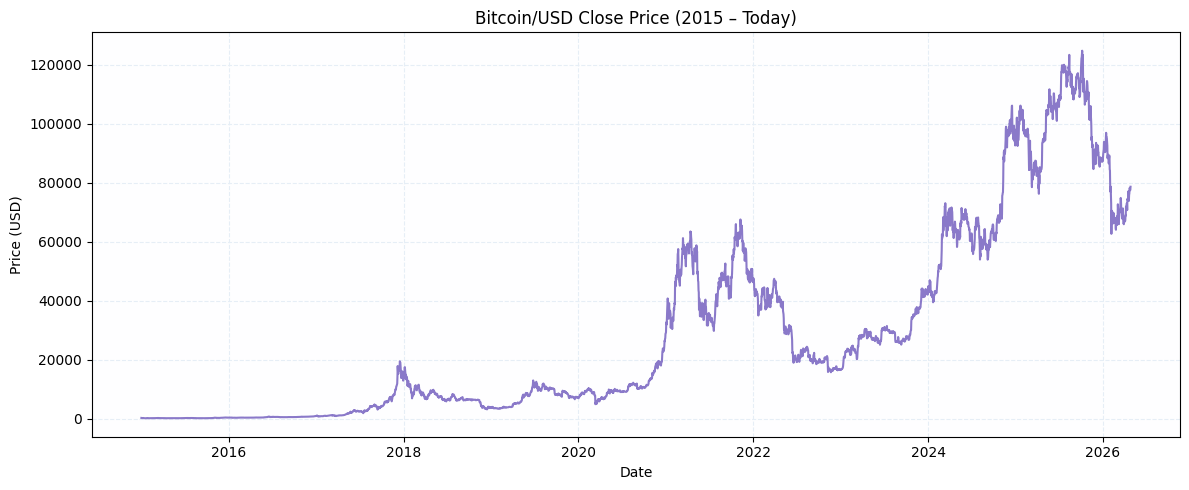

In [4]:
# Quick visualization of Close price
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color=PALETTE['close'], linewidth=1.5)
plt.title('Bitcoin/USD Close Price (2015 – Today)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

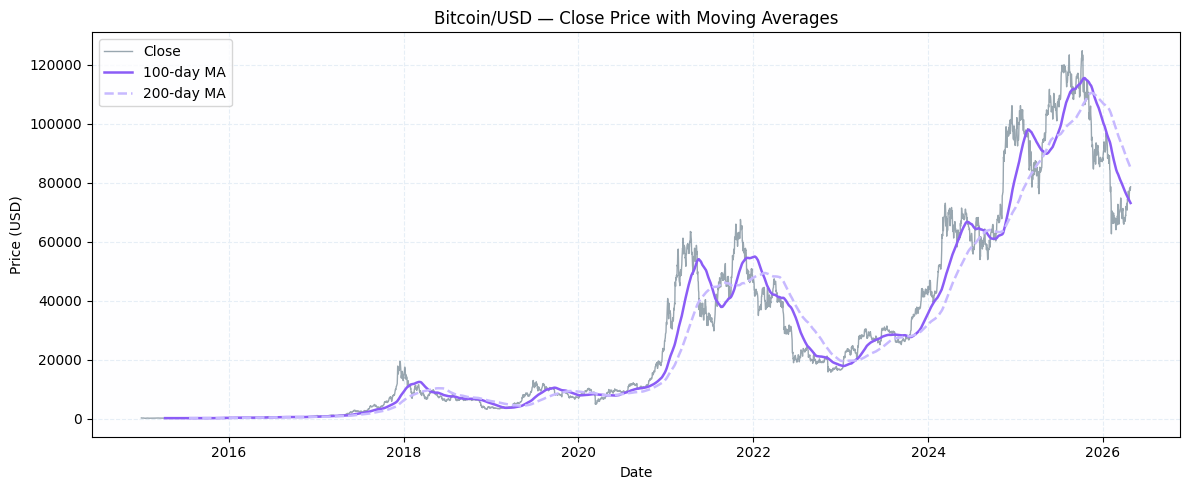

In [5]:
# Moving averages — 100 day and 200 day
ma100 = df['Close'].rolling(100).mean()
ma200 = df['Close'].rolling(200).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close',       color=PALETTE['actual'], alpha=0.6, linewidth=1)
plt.plot(df['Date'], ma100,       label='100-day MA',  color=PALETTE['ma100'],  linewidth=1.8)
plt.plot(df['Date'], ma200,       label='200-day MA',  color=PALETTE['ma200'],  linewidth=1.8, linestyle='--')
plt.title('Bitcoin/USD — Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature engineering helpers ───────────────────────────────────────
LOOKBACK = 20   # GRU sequence length (timesteps fed into the model)
SEQ_LEN  = LOOKBACK  # lag window length = LOOKBACK (GRU-only notebook)

def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    up    = delta.clip(lower=0).rolling(period).mean()
    down  = -delta.clip(upper=0).rolling(period).mean()
    return 100 - (100 / (1 + up / down))

def macd_features(series: pd.Series, a=12, b=26, c=9):
    ema_a = series.ewm(span=a, adjust=False).mean()
    ema_b = series.ewm(span=b, adjust=False).mean()
    line  = ema_a - ema_b
    sig   = line.ewm(span=c, adjust=False).mean()
    return line, sig

def build_features(df: pd.DataFrame, seq_len: int = SEQ_LEN) -> pd.DataFrame:
    """Build a leak-free feature matrix from raw OHLCV data.

    WHY shift by 1?
    ---------------
    When predicting close[t], the model must only see information that was
    available *before* day t opened — i.e. up to and including close[t-1].
    Without .shift(1), an indicator computed from close[t] would leak future
    information into the feature for that same row, producing unrealistically
    good backtested metrics and a model that fails in live trading.

    Which features need shifting and why:
      • return, std30, rsi14, macd, macd_sig — all computed using a rolling
        or EMA window that includes close[t], so they must be shifted.
      • lag_1 … lag_20 — already reference close[t-1] … close[t-20] by
        construction, so they are inherently leak-free (no shift needed).
    """
    d = df[['Date', 'Close']].copy()

    # ── Indicators that include close[t] → shift so row t gets yesterday's value ──
    d["return"]   = d["Close"].pct_change().shift(1)       # yesterday's 1-day return
    d["std30"]    = d["Close"].rolling(30).std().shift(1)  # 30-day volatility as of yesterday
    d["rsi14"]    = rsi(d["Close"]).shift(1)               # RSI(14) as of yesterday
    ml, ms        = macd_features(d["Close"])
    d["macd"]     = ml.shift(1)                            # MACD line as of yesterday
    d["macd_sig"] = ms.shift(1)                            # MACD signal as of yesterday
    d = d.dropna().reset_index(drop=True)

    # ── Lag prices: lag_1 = close[t-1], lag_2 = close[t-2], …
    # Inherently leak-free — they reference past closes by definition. ──────────────
    for i in range(1, seq_len + 1):
        d[f"lag_{i}"] = d["Close"].shift(i)
    d = d.dropna().reset_index(drop=True)
    return d

print("Feature engineering helpers defined.")


Feature engineering helpers defined.


## Step 2 — Feature Engineering & Preprocessing

### Lookahead leakage — what it is and why it matters

**Lookahead leakage** occurs when a feature used to predict `close[t]` is computed using `close[t]` itself (or any later value). The model learns from information it could never have in a real trading scenario, producing metrics that look great in testing but fail completely in production.

**How we prevent it:** every indicator derived from the closing-price series is shifted forward by 1 day with `.shift(1)`. This means the value stored in row `t` reflects the indicator as it stood at the *end of day t-1* — exactly what a trader would know before day `t` opens.

| Feature | Computed from | `.shift(1)` applied? | Reason |
|---|---|---|---|
| `return` | `close[t]` via `pct_change()` | ✅ Yes | uses today's close |
| `std30` | rolling window ending at `close[t]` | ✅ Yes | window includes today |
| `rsi14` | rolling window ending at `close[t]` | ✅ Yes | window includes today |
| `macd` / `macd_sig` | EMA ending at `close[t]` | ✅ Yes | EMA includes today |
| `lag_1 … lag_20` | `close[t-1]` … `close[t-20]` | ❌ No — already safe | reference past closes by definition |

### Other preprocessing choices

- **Target:** log-return `log(close[t] / close[t-1])` — stationary and avoids price-range extrapolation issues with tree models
- **MinMaxScaler** on features (X); **StandardScaler** on log-return target (y — can be negative, so MinMax is inappropriate)
- **Train/test split: 70% / 30%** — chronological, no shuffling (shuffling would cause leakage across the split boundary)
- **GRU sequences:** `LOOKBACK = 20` timesteps of scaled lag prices fed in oldest → newest order


In [7]:
# ── Build features & prepare train/test splits ────────────────────────
feat_df = build_features(df, seq_len=SEQ_LEN)

lag_cols     = [f"lag_{i}" for i in range(1, SEQ_LEN + 1)]
extra_cols   = ["std30", "rsi14", "macd", "macd_sig", "return"]
feature_cols = lag_cols + extra_cols

X      = feat_df[feature_cols].copy()
dates  = feat_df["Date"].copy()

# Target: log-return (stationary — avoids price-range extrapolation)
y = np.log(feat_df["Close"] / feat_df["lag_1"])

split = int(len(X) * 0.70)
X_train, X_test = X.iloc[:split],  X.iloc[split:]
y_train, y_test = y.iloc[:split],  y.iloc[split:]
dates_test = dates.iloc[split:].reset_index(drop=True)

# Kept for price reconstruction during evaluation
close_test_actual = feat_df["Close"].iloc[split:].values
close_prev_test   = X_test["lag_1"].values

# Scale features (fit on train only)
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

# GRU sequences: LOOKBACK timesteps of lag prices (oldest → newest)
gru_lag_idx = list(range(LOOKBACK - 1, -1, -1))  # [19, 18, ..., 0]
X_train_gru = X_train_s[:, gru_lag_idx].reshape(-1, LOOKBACK, 1)
X_test_gru  = X_test_s[:,  gru_lag_idx].reshape(-1, LOOKBACK, 1)

print(f"Total samples: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Features: {len(feature_cols)}  (lag×{SEQ_LEN} + 5 indicators, all leak-free)")
print(f"GRU input shape — train: {X_train_gru.shape}  |  test: {X_test_gru.shape}")

Total samples: 4004 | Train: 2802 | Test: 1202
Features: 105  (lag×100 + 5 indicators, all leak-free)
GRU input shape — train: (2802, 20, 1)  |  test: (1202, 20, 1)


C:\Users\bruno\AppData\Local\Temp\ipykernel_61316\1581787893.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d[f"lag_{i}"] = d["Close"].shift(i)
C:\Users\bruno\AppData\Local\Temp\ipykernel_61316\1581787893.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d[f"lag_{i}"] = d["Close"].shift(i)


## Step 3 — Build & Train GRU

The **GRU (Gated Recurrent Unit)** is a recurrent neural network well-suited for sequential time series. It processes `LOOKBACK=20` timesteps of normalised lag prices and predicts the next-day log-return, which is then reconstructed back to a price for evaluation.

Each training run is logged in MLflow under the **`bitcoin-price-prediction`** experiment.

In [8]:
# ── Build & Train GRU ─────────────────────────────────────────────────
REPO_ROOT  = os.path.dirname(os.getcwd())
MLFLOW_DIR = os.path.join(REPO_ROOT, 'mlflow')
MODELS_DIR = os.path.join(REPO_ROOT, 'models')
os.makedirs(MLFLOW_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{os.path.join(MLFLOW_DIR, 'mlflow.db')}")
mlflow.set_experiment("bitcoin-price-prediction")

GRU_EPOCHS     = 50
GRU_BATCH_SIZE = 32

gru_model = Sequential([
    GRU(64, input_shape=(LOOKBACK, 1)),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

with mlflow.start_run(run_name="gru-btc-usd"):
    mlflow.log_param("model",       "GRU")
    mlflow.log_param("ticker",      "BTC-USD")
    mlflow.log_param("seq_len",     SEQ_LEN)
    mlflow.log_param("lookback",    LOOKBACK)
    mlflow.log_param("epochs_max",  GRU_EPOCHS)
    mlflow.log_param("batch_size",  GRU_BATCH_SIZE)
    mlflow.log_param("train_size",  len(X_train_gru))
    mlflow.log_param("test_size",   len(X_test_gru))

    history = gru_model.fit(
        X_train_gru, y_train_s,
        epochs=GRU_EPOCHS,
        batch_size=GRU_BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    best_epoch = (early_stop.stopped_epoch - early_stop.patience + 1
                  if early_stop.stopped_epoch else GRU_EPOCHS)
    print(f"\nTraining complete — best epoch: {best_epoch}")

c:\Users\bruno\Desktop\Ironhack\labs\capstone-ml-on-cloud\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.0303 - val_loss: 0.7460
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0296 - val_loss: 0.7372
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0293 - val_loss: 0.7401
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0292 - val_loss: 0.7384
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0298 - val_loss: 0.7531
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0290 - val_loss: 0.7387
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0291 - val_loss: 0.7415
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0294 - val_loss: 0.7403
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0291 - val_loss: 0.7397
Epoch 10/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0293 - val_loss: 0.7399
Epoch 11/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0289 - val_loss: 0.7351
Epoch 12/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0281 - val_l

## Step 4 — Evaluate, Save & Plot

Evaluate the GRU on the held-out 30% test set, log metrics to MLflow, save model artifacts, and visualise predictions vs actual prices.

| Metric | Description |
|--------|-------------|
| **MAE** | Mean Absolute Error in USD — average absolute deviation |
| **RMSE** | Root Mean Squared Error in USD — penalises large errors more |
| **R²** | Proportion of price variance explained (1.0 = perfect) |
| **MAE %** | MAE as a percentage of mean test price |

,MAE (USD),RMSE (USD),R²,MAE %
Model,,,,
GRU,"$1,179","$1,756",0.9966,1.76%



GRU  →  MAE: $1,179  |  RMSE: $1,756  |  R²: 0.9966
Model saved      → c:\Users\bruno\Desktop\Ironhack\labs\capstone-ml-on-cloud\models\best_model.keras
selection.json   → c:\Users\bruno\Desktop\Ironhack\labs\capstone-ml-on-cloud\models\selection.json


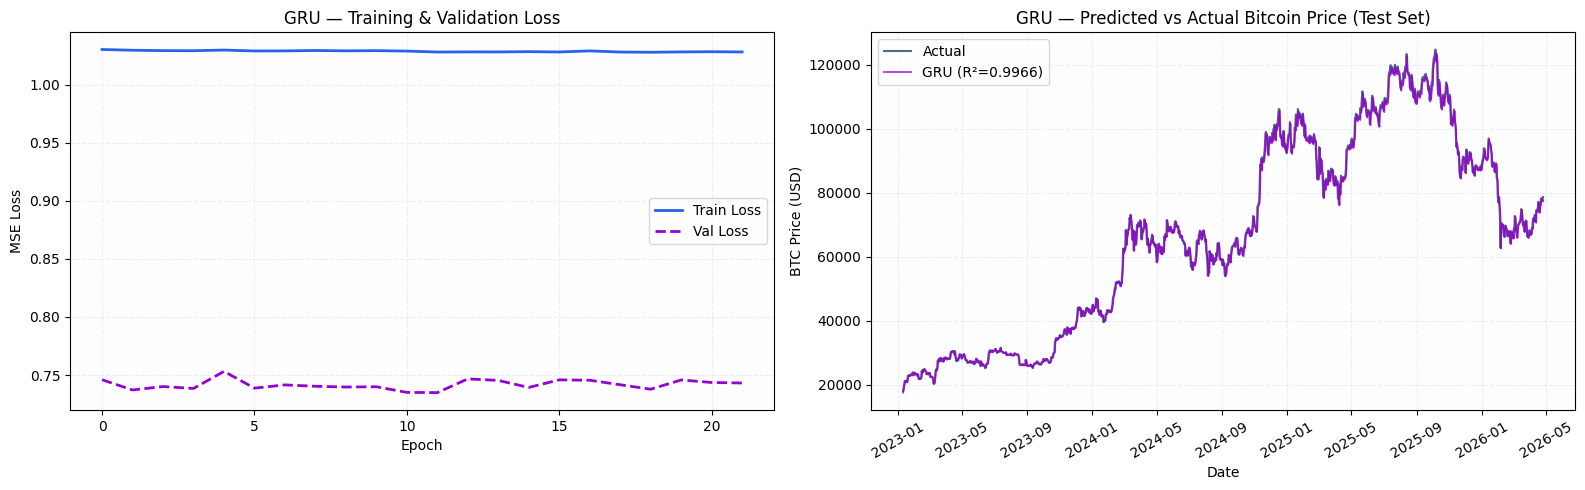

In [9]:
# ── Helper: inverse-transform log-return → reconstructed price ────────
def inv_logret(scaled_pred, close_prev):
    """Unscale log-return prediction → reconstruct price.
    price[t] = close_prev[t] * exp(log_return[t])
    """
    log_ret = scaler_y.inverse_transform(scaled_pred.reshape(-1, 1)).ravel()
    return close_prev * np.exp(log_ret)

# ── GRU predictions on the test set ──────────────────────────────────
gru_pred_s = gru_model.predict(X_test_gru, verbose=0).ravel()
gru_pred   = inv_logret(gru_pred_s, close_prev_test)

gru_mae  = mean_absolute_error(close_test_actual, gru_pred)
gru_rmse = float(np.sqrt(np.mean((close_test_actual - gru_pred) ** 2)))
gru_r2   = r2_score(close_test_actual, gru_pred)
mean_price = float(np.mean(close_test_actual))

# Log metrics into MLflow run
try:
    runs = mlflow.search_runs(filter_string="tags.`mlflow.runName` = 'gru-btc-usd'",
                              order_by=["start_time DESC"])
    if not runs.empty:
        with mlflow.start_run(run_id=runs.iloc[0].run_id):
            mlflow.log_metric("mae_usd",  gru_mae)
            mlflow.log_metric("rmse_usd", gru_rmse)
            mlflow.log_metric("r2",       gru_r2)
            mlflow.log_metric("mae_pct",  (gru_mae / mean_price) * 100)
except Exception:
    pass  # metrics printed below regardless

# ── Results table ─────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model':      ['GRU'],
    'MAE (USD)':  [gru_mae],
    'RMSE (USD)': [gru_rmse],
    'R²':         [gru_r2],
    'MAE %':      [(gru_mae / mean_price) * 100],
}).set_index('Model')

styled = (
    results.style
    .format({'MAE (USD)': '${:,.0f}', 'RMSE (USD)': '${:,.0f}',
             'R²': '{:.4f}', 'MAE %': '{:.2f}%'})
    .set_caption('GRU — Test set metrics (price reconstructed from predicted log-returns)')
)
display(styled)
print(f"\nGRU  →  MAE: ${gru_mae:,.0f}  |  RMSE: ${gru_rmse:,.0f}  |  R²: {gru_r2:.4f}")

# ── Save artifacts ────────────────────────────────────────────────────
model_path    = os.path.join(MODELS_DIR, 'best_model.keras')
scaler_y_path = os.path.join(MODELS_DIR, 'scaler_y.pkl')
scaler_X_path = os.path.join(MODELS_DIR, 'scaler_X.pkl')

gru_model.save(model_path)
joblib.dump(scaler_y, scaler_y_path)
joblib.dump(scaler_X, scaler_X_path)

selection = {
    "model_type":   "gru",
    "model_path":   model_path,
    "rmse":         gru_rmse,
    "features":     feature_cols,
    "gru_lookback": LOOKBACK,
}
sel_path = os.path.join(MODELS_DIR, 'selection.json')
with open(sel_path, "w") as f:
    json.dump(selection, f, indent=2)

print(f"Model saved      → {model_path}")
print(f"selection.json   → {sel_path}")

# ── Training loss curve ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#2563EB', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color=PALETTE['gru'], linewidth=2, linestyle='--')
axes[0].set_title('GRU — Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# ── Predictions vs Actuals ────────────────────────────────────────────
axes[1].plot(dates_test.values, close_test_actual, color=PALETTE['actual'], lw=1.5, label='Actual')
axes[1].plot(dates_test.values, gru_pred,           color=PALETTE['gru'],   lw=1.2, alpha=0.85,
             label=f'GRU (R²={gru_r2:.4f})')
axes[1].set_title('GRU — Predicted vs Actual Bitcoin Price (Test Set)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('BTC Price (USD)')
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

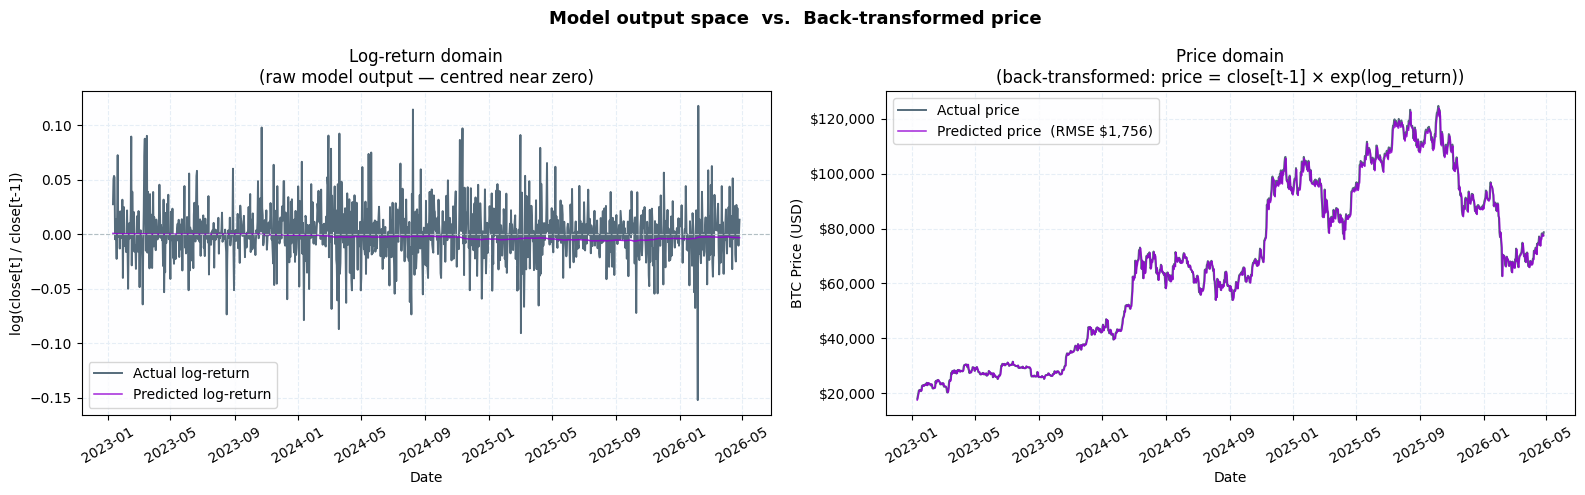

Notice:
  Left plot  — log-returns fluctuate around zero, small range (~±0.1). The model predicts these small values.
  Right plot — prices are in USD ($thousands). Small errors in log-return space become larger in USD at higher prices.


In [10]:
# ── Log-return vs Price comparison ───────────────────────────────────
#
# The model outputs a log-return (what it was trained on).
# That gets back-transformed to a price via: price[t] = close[t-1] * exp(log_return)
# This plot shows both representations side by side so you can see the difference.

# Actual log-returns (from the test set target)
actual_log_rets = y_test.values

# Predicted log-returns (unscale the model's raw output)
pred_log_rets = scaler_y.inverse_transform(gru_pred_s.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Model output space  vs.  Back-transformed price", fontsize=13, fontweight="bold")

# ── Left: log-return domain (what the model actually predicts) ────────
axes[0].plot(dates_test.values, actual_log_rets, color=PALETTE['actual'], lw=1.4, label='Actual log-return')
axes[0].plot(dates_test.values, pred_log_rets,   color=PALETTE['gru'],   lw=1.1, alpha=0.85, label='Predicted log-return')
axes[0].axhline(0, color='#B2BEC3', lw=0.8, linestyle='--')
axes[0].set_title('Log-return domain\n(raw model output — centred near zero)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('log(close[t] / close[t-1])')
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=30)

# ── Right: price domain (after back-transformation) ───────────────────
axes[1].plot(dates_test.values, close_test_actual, color=PALETTE['actual'], lw=1.4, label='Actual price')
axes[1].plot(dates_test.values, gru_pred,           color=PALETTE['gru'],   lw=1.1, alpha=0.85,
             label=f'Predicted price  (RMSE ${gru_rmse:,.0f})')
axes[1].set_title('Price domain\n(back-transformed: price = close[t-1] × exp(log_return))')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('BTC Price (USD)')
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print("Notice:")
print("  Left plot  — log-returns fluctuate around zero, small range (~±0.1). The model predicts these small values.")
print("  Right plot — prices are in USD ($thousands). Small errors in log-return space become larger in USD at higher prices.")


## Step 5 — MLOps & Deployment Roadmap

### Tier 1 — Version Control ✅ (complete)
- [x] Git repository initialised
- [x] Virtual environment (`venv`) for dependency isolation
- [x] `requirements.txt` committed

### Tier 2 — Experiment Tracking & Cloud Deployment ✅ (complete)
- [x] MLflow experiment tracking — GRU run logged under **`bitcoin-price-prediction`**
- [x] Best model artifact saved (`models/best_model.keras`) with `selection.json`
- [x] Deploy on **Oracle Cloud** (`VM.Standard.E2.1.Micro` — Always Free, Frankfurt `eu-frankfurt-1`)
- [x] Build **FastAPI** REST endpoint (`POST /predict` + `GET /predict/latest` → next-day BTC price)
- [x] Automated data pipeline: daily fetch → feature engineering → drift detection → conditional retrain (`src/training/retrain.py`)
- [x] Model monitoring: recent MAE tracked over last 30 days; retraining triggered when MAE > 1.5 × baseline RMSE

### Tier 3 — Containerisation ✅ (complete)
- [x] `Dockerfile` written — packages FastAPI app + GRU model artifact
- [x] Docker image pushed to **Docker Hub** (`brunopulheze/btc-predictor:latest`)
- [x] Container deployed on Oracle Cloud VM via `docker run --restart unless-stopped`

### Tier 4 (Advanced) — CI/CD ✅ (complete)
- [x] GitHub Actions workflow (`.github/workflows/retrain.yml`): runs daily at 06:00 UTC → drift check → if retrained: rebuild Docker image → push to Docker Hub → SSH redeploy on Oracle Cloud VM

### Bonus
- [ ] Price-change alerting via email / Telegram bot
- [ ] Monitoring dashboard via **Grafana** or similar